# Check RGB-Mask Pairs

In [4]:
import os

image_dir = "rgb"
mask_dir = "BW"

# Get all files
rgb_files = set([
    os.path.splitext(f)[0]
    for f in os.listdir(image_dir)
    if f.lower().endswith(('.jpg', '.jpeg'))
])

mask_files = set([f.replace('.png', '') for f in os.listdir(mask_dir) if f.endswith('.png')])

# Find missing pairs
rgb_without_mask = rgb_files - mask_files
mask_without_rgb = mask_files - rgb_files

# Display results
print(f"📊 RGB-Mask Pairs Check:")
print(f"{'='*60}")
print(f"Total RGB files (.jpg):  {len(rgb_files)}")
print(f"Total Mask files (.png): {len(mask_files)}")
print(f"{'='*60}")

if not rgb_without_mask and not mask_without_rgb:
    print("✅ ALL PAIRS MATCHED! Every RGB has a mask and vice versa.")
else:
    print(f"❌ MISSING PAIRS DETECTED:")
    print(f"   RGB without mask: {len(rgb_without_mask)}")
    print(f"   Mask without RGB: {len(mask_without_rgb)}")
    
    if rgb_without_mask:
        print(f"\n📋 RGB files without mask (first 10):")
        for f in sorted(list(rgb_without_mask))[:10]:
            print(f"   - {f}.jpg")
        if len(rgb_without_mask) > 10:
            print(f"   ... and {len(rgb_without_mask) - 10} more")
    
    if mask_without_rgb:
        print(f"\n📋 Mask files without RGB (first 10):")
        for f in sorted(list(mask_without_rgb))[:10]:
            print(f"   - {f}.png")
        if len(mask_without_rgb) > 10:
            print(f"   ... and {len(mask_without_rgb) - 10} more")

print(f"\n{'='*60}")
print(f"✅ Matched pairs: {len(rgb_files & mask_files)}")

📊 RGB-Mask Pairs Check:
Total RGB files (.jpg):  259
Total Mask files (.png): 259
✅ ALL PAIRS MATCHED! Every RGB has a mask and vice versa.

✅ Matched pairs: 259


# Binarize Mask

In [3]:
import cv2
import os
import numpy as np

mask_dir = "bw2"

for fname in os.listdir(mask_dir):

    path = os.path.join(mask_dir, fname)

    mask = cv2.imread(path, 0)

    if mask is None:
        continue

    # ===== BINARIZE =====
    mask = (mask > 127).astype(np.uint8) * 255

    # ===== SAVE ulang sebagai PNG (PENTING) =====
    new_path = os.path.join(mask_dir, fname.replace(".jpg", ".png"))
    cv2.imwrite(new_path, mask)

print("Mask converted to binary PNG")

Mask converted to binary PNG


In [1]:
import numpy as np
import cv2
mask = cv2.imread("BW/111.png", 0)
print(np.unique(mask))


[  0 255]


# Delete JPG Mask

In [4]:
import os
from pathlib import Path

# GANTI path_folder di bawah dengan folder yang ingin dibersihkan
path_folder = "bw2"

folder = Path(path_folder)

# Cek apakah folder ada
if not folder.is_dir():
    print(f"Folder tidak ditemukan: {folder}")
else:
    # Hapus semua file dengan ekstensi .jpg atau .JPG
    count = 0
    for ext in ("*.jpg", "*.JPG", "*.jpeg", "*.JPEG"):
        for file in folder.glob(ext):
            try:
                file.unlink()
                print(f"Deleted: {file.name}")
                count += 1
            except Exception as e:
                print(f"Gagal hapus {file.name}: {e}")

    print(f"Selesai. Total file terhapus: {count}")

Deleted: 001.jpg
Deleted: 011.jpg
Deleted: 017.jpg
Deleted: 018.jpg
Deleted: 019.jpg
Deleted: 020.jpg
Deleted: 021.jpg
Deleted: 023.jpg
Deleted: 024.jpg
Deleted: 025.jpg
Deleted: 026.jpg
Deleted: 027.jpg
Deleted: 028.jpg
Deleted: 029.jpg
Deleted: 030.jpg
Deleted: 031.jpg
Deleted: 032.jpg
Deleted: 034.jpg
Deleted: 035.jpg
Deleted: 036.jpg
Deleted: 037.jpg
Deleted: 038.jpg
Deleted: 039.jpg
Deleted: 040.jpg
Deleted: 041.jpg
Deleted: 042.jpg
Deleted: 043.jpg
Deleted: 045.jpg
Deleted: 046.jpg
Deleted: 047.jpg
Selesai. Total file terhapus: 30


# Delete non-4032x3024 dari folder rgb dan BW

In [6]:
import cv2
import os
from tqdm import tqdm

image_dir = "rgb"
mask_dir  = "BW"

TARGET_W = 4032
TARGET_H = 3024

deleted = 0
kept    = 0

for file in tqdm(os.listdir(image_dir)):

    if not file.endswith(".jpg"):
        continue

    name = os.path.splitext(file)[0]

    img_path  = os.path.join(image_dir, file)
    mask_path = os.path.join(mask_dir, name + ".png")

    # kalau mask ga ada → delete image
    if not os.path.exists(mask_path):
        os.remove(img_path)
        deleted += 1
        continue

    img  = cv2.imread(img_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if img is None or mask is None:
        if os.path.exists(img_path):
            os.remove(img_path)
        if os.path.exists(mask_path):
            os.remove(mask_path)
        deleted += 1
        continue

    h1, w1 = img.shape[:2]
    h2, w2 = mask.shape[:2]

    # Cek apakah RGB 4032x3024, jika tidak hapus keduanya
    if (w1 != TARGET_W or h1 != TARGET_H or
        w2 != TARGET_W or h2 != TARGET_H):

        os.remove(img_path)
        os.remove(mask_path)
        deleted += 1

    else:
        kept += 1

print(f"✅ Kept    : {kept}")
print(f"❌ Deleted: {deleted}")

100%|██████████| 458/458 [00:32<00:00, 13.99it/s]

✅ Kept    : 237
❌ Deleted: 20


# Delete Portrait (3024x4032) - Duplicate

In [7]:
import cv2
import os
from tqdm import tqdm

image_dir = "rgb"
mask_dir  = "BW"

TARGET_W = 4032
TARGET_H = 3024

deleted = 0
kept = 0

for file in tqdm(os.listdir(image_dir)):

    if not file.endswith(".jpg"):
        continue

    name = os.path.splitext(file)[0]

    img_path  = os.path.join(image_dir, file)
    mask_path = os.path.join(mask_dir, name + ".png")

    if not os.path.exists(mask_path):
        kept += 1
        continue

    img  = cv2.imread(img_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if img is None or mask is None:
        kept += 1
        continue

    h1, w1 = img.shape[:2]
    h2, w2 = mask.shape[:2]

    # Jika portrait (3024x4032), hapus karena duplicate
    if (h1 == TARGET_W and w1 == TARGET_H and 
        h2 == TARGET_W and w2 == TARGET_H):
        
        # Hapus RGB dan mask
        os.remove(img_path)
        os.remove(mask_path)
        
        deleted += 1
    else:
        kept += 1

print(f"✅ Kept    : {kept}")
print(f"❌ Deleted: {deleted}")

100%|██████████| 438/438 [00:28<00:00, 15.28it/s]

✅ Kept    : 237
❌ Deleted: 0


# EDA - Deteksi Duplikat & Analisis Mask

## Visualisasi Distribusi

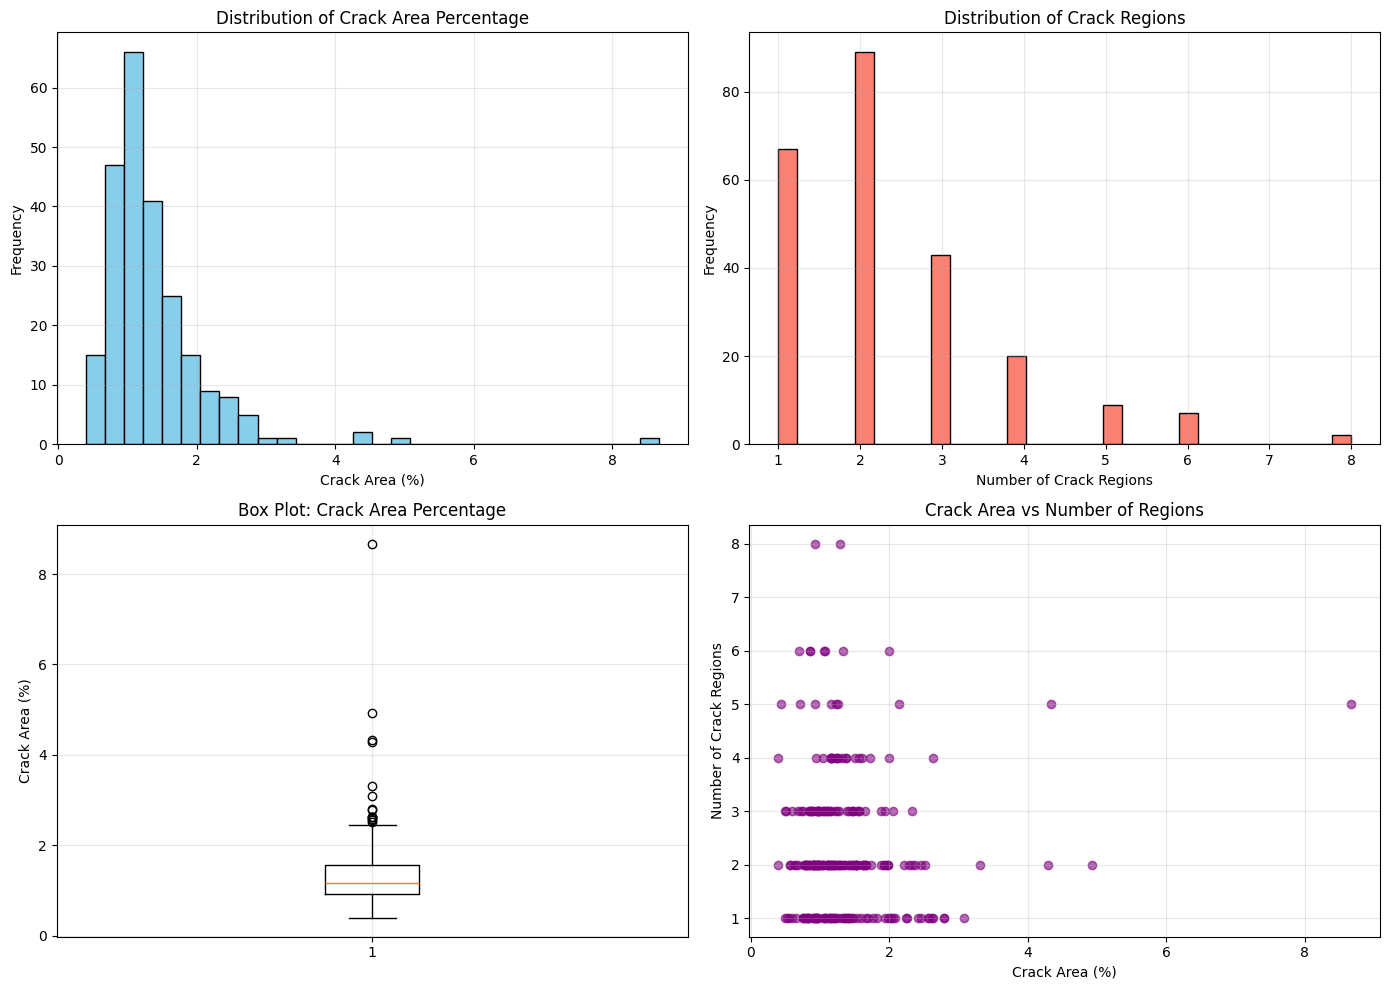

✅ Plots saved to: mask_analysis_plots.png


In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram crack percentage
axes[0, 0].hist(df['crack_percentage'], bins=30, edgecolor='black', color='skyblue')
axes[0, 0].set_xlabel('Crack Area (%)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Crack Area Percentage')
axes[0, 0].grid(True, alpha=0.3)

# 2. Histogram jumlah region
axes[0, 1].hist(df['num_crack_regions'], bins=30, edgecolor='black', color='salmon')
axes[0, 1].set_xlabel('Number of Crack Regions')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Crack Regions')
axes[0, 1].grid(True, alpha=0.3)

# 3. Box plot crack percentage
axes[1, 0].boxplot(df['crack_percentage'], vert=True)
axes[1, 0].set_ylabel('Crack Area (%)')
axes[1, 0].set_title('Box Plot: Crack Area Percentage')
axes[1, 0].grid(True, alpha=0.3)

# 4. Scatter plot: crack area vs regions
axes[1, 1].scatter(df['crack_percentage'], df['num_crack_regions'], alpha=0.6, color='purple')
axes[1, 1].set_xlabel('Crack Area (%)')
axes[1, 1].set_ylabel('Number of Crack Regions')
axes[1, 1].set_title('Crack Area vs Number of Regions')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mask_analysis_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Plots saved to: mask_analysis_plots.png")

## Visualisasi Sample Images

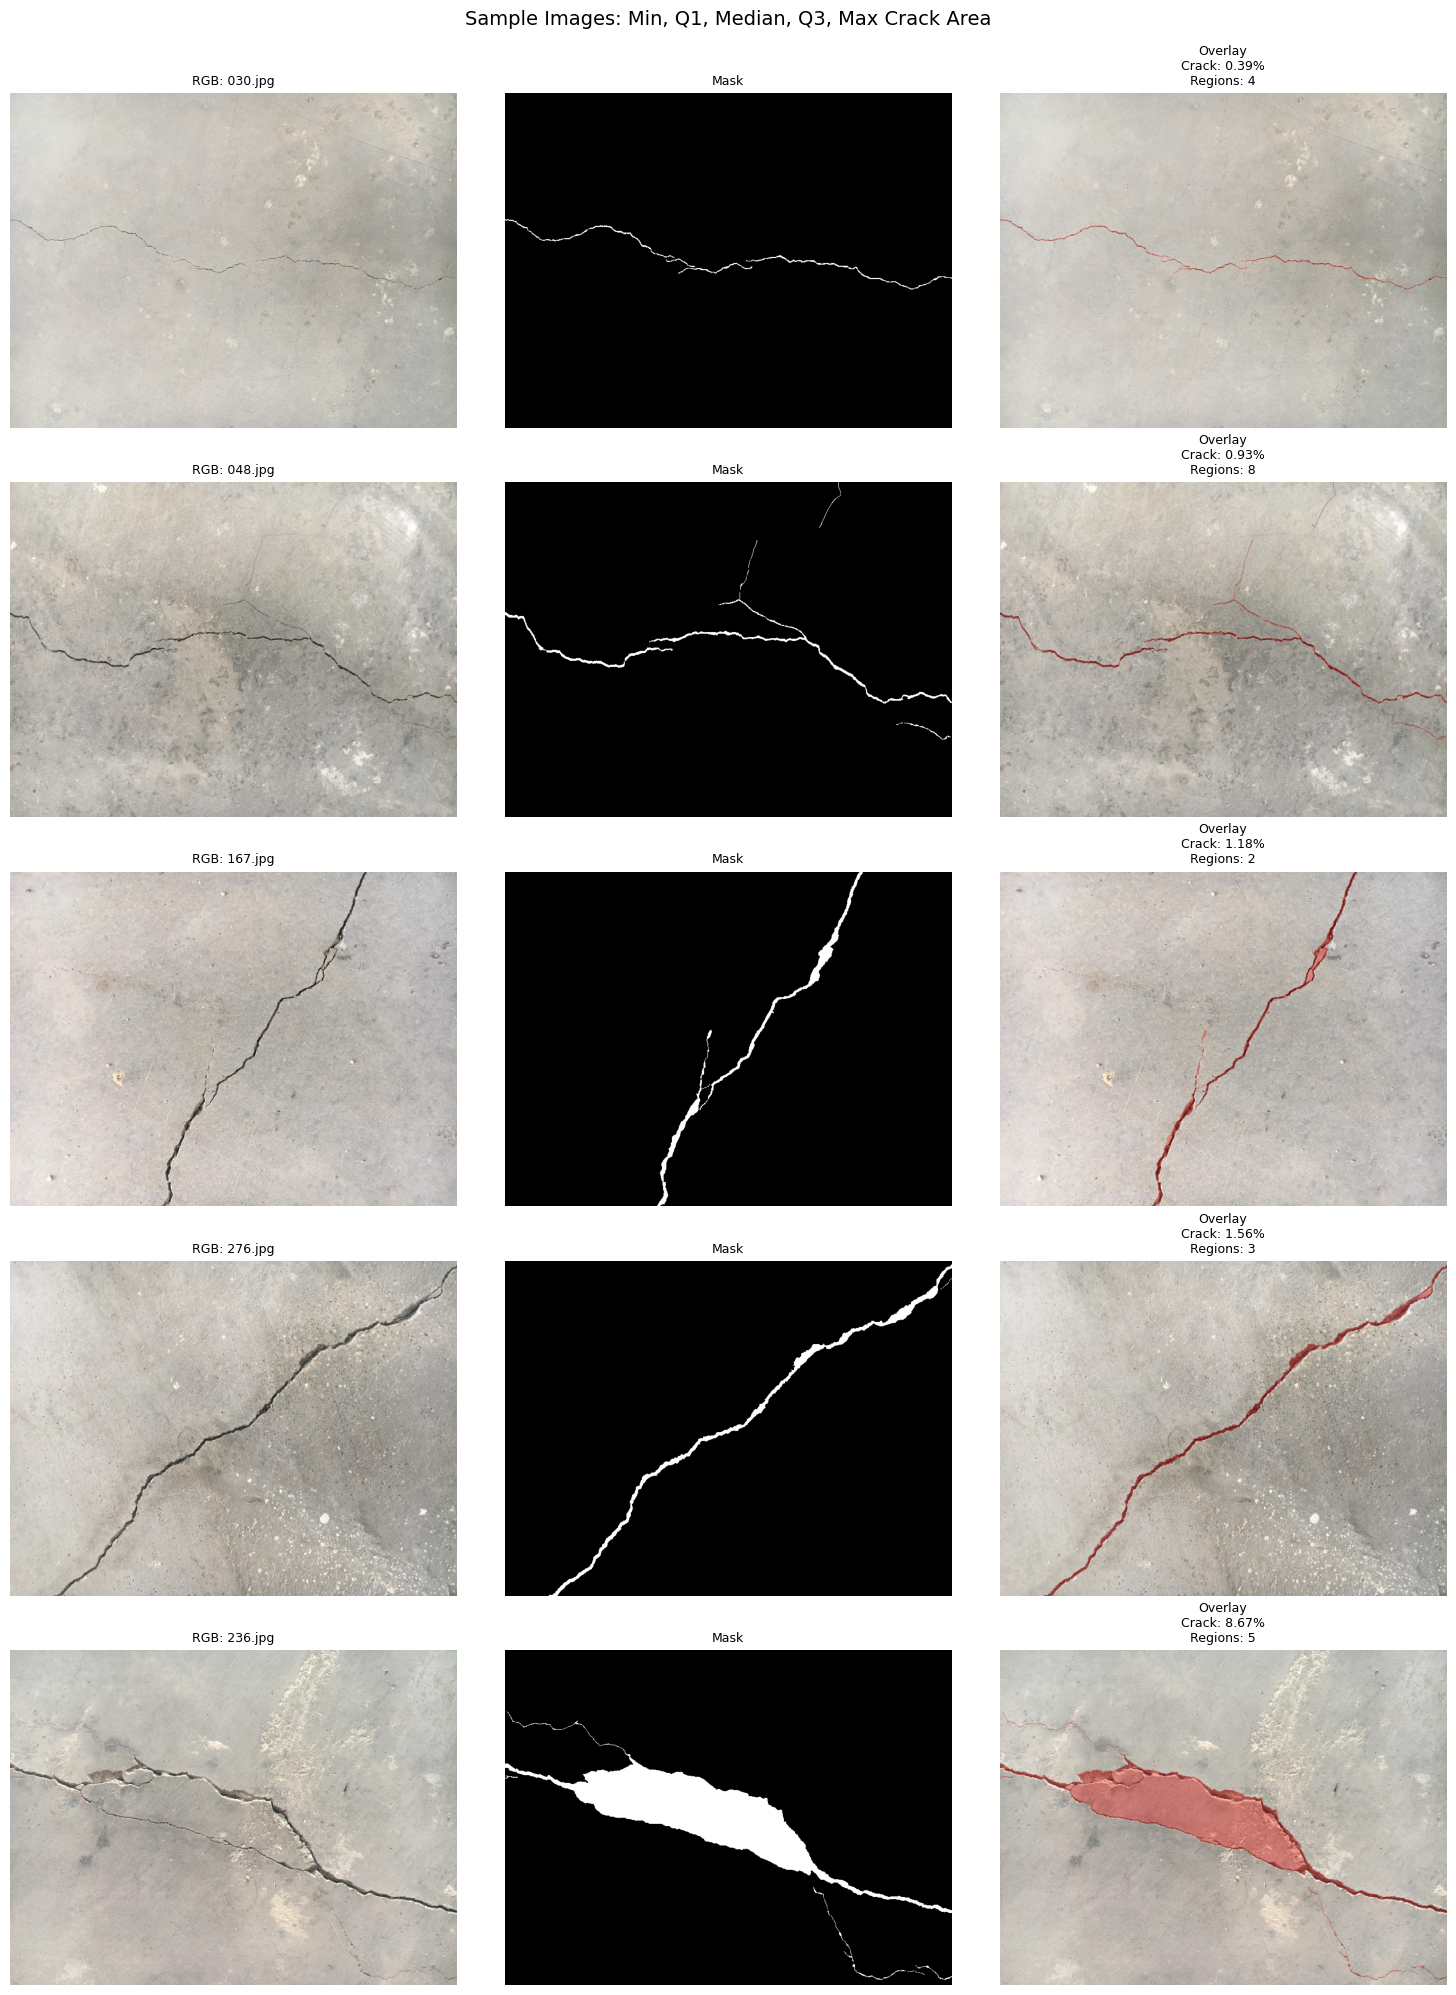

✅ Sample images saved to: sample_images.png


In [11]:
import cv2
import matplotlib.pyplot as plt
import random

# Ambil sample dengan berbagai crack percentage
df_sorted = df.sort_values('crack_percentage')
samples = [
    df_sorted.iloc[0]['filename'],  # Min crack
    df_sorted.iloc[len(df_sorted)//4]['filename'],  # Q1
    df_sorted.iloc[len(df_sorted)//2]['filename'],  # Median
    df_sorted.iloc[3*len(df_sorted)//4]['filename'],  # Q3
    df_sorted.iloc[-1]['filename'],  # Max crack
]

fig, axes = plt.subplots(5, 3, figsize=(15, 20))

for i, filename in enumerate(samples):
    name = os.path.splitext(filename)[0]
    
    # Load image dan mask
    img = cv2.imread(os.path.join(image_dir, filename))
    mask = cv2.imread(os.path.join(mask_dir, name + ".png"), cv2.IMREAD_GRAYSCALE)
    
    if img is not None and mask is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Resize untuk visualisasi
        scale = 0.2
        img_small = cv2.resize(img_rgb, None, fx=scale, fy=scale)
        mask_small = cv2.resize(mask, None, fx=scale, fy=scale)
        
        # Create overlay
        overlay = img_small.copy()
        overlay[mask_small > 0] = [255, 0, 0]  # Red untuk crack
        result = cv2.addWeighted(img_small, 0.7, overlay, 0.3, 0)
        
        # Get stats
        stats = df[df['filename'] == filename].iloc[0]
        
        # Plot RGB
        axes[i, 0].imshow(img_small)
        axes[i, 0].set_title(f'RGB: {filename}', fontsize=9)
        axes[i, 0].axis('off')
        
        # Plot Mask
        axes[i, 1].imshow(mask_small, cmap='gray')
        axes[i, 1].set_title(f'Mask', fontsize=9)
        axes[i, 1].axis('off')
        
        # Plot Overlay
        axes[i, 2].imshow(result)
        axes[i, 2].set_title(f'Overlay\nCrack: {stats["crack_percentage"]:.2f}%\nRegions: {stats["num_crack_regions"]}', 
                             fontsize=9)
        axes[i, 2].axis('off')

plt.suptitle('Sample Images: Min, Q1, Median, Q3, Max Crack Area', fontsize=14, y=0.995)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Sample images saved to: sample_images.png")